# <p style="background-color:Purple; font-family:calibri; color:White; font-size:150%; text-align:center; border-radius:15px 50px;">Airlines Passenger Satisfaction EDA</p>

<center><a><img src="https://apartmentinteriors.ru/wp-content/uploads/samolot-charter-private-jet-charter-02.jpg" border="3" width=800 height=600 class="center"></a>

<a id="import"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

<a id="read"></a>
# <p style="background-color:purple ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

In [2]:
df = pd.read_csv('test.csv')

<a id="overview"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview & Cleaning</p>

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">
    
Next, I'll delve into a detailed exploration of the dataset:

In [3]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [4]:
# Drop obvious index columns
to_drop = [c for c in ['Unnamed: 0','id'] if c in df.columns]
if to_drop:
    df = df.drop(columns=to_drop)


print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)


Columns:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

Data types:
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding              

In [5]:
# Quick look
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [6]:
# Data quality checks
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print('\nMissing values by column:')
print(missing[missing>0])

# Duplicates
dups = df.duplicated().sum()
print(f"\nDuplicate rows: {dups}")

# Basic statistics
display(df.describe(include='all'))


Missing values by column:
Arrival Delay in Minutes    83
dtype: int64

Duplicate rows: 0


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,25976,25976,25976.000000,25976,25976,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,...,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000,25976
unique,2,2,NaN,2,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,Female,Loyal Customer,NaN,Business travel,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral or dissatisfied
freq,13172,21177,NaN,18038,12495,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14573
mean,NaN,NaN,39.620958,NaN,NaN,1193.788459,2.724746,3.046812,2.756775,2.977094,...,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857,NaN
std,NaN,NaN,15.135685,NaN,NaN,998.683999,1.335384,1.533371,1.412951,1.282133,...,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539,NaN
min,NaN,NaN,7.000000,NaN,NaN,31.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,NaN
25%,NaN,NaN,27.000000,NaN,NaN,414.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000,NaN
50%,NaN,NaN,40.000000,NaN,NaN,849.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000,NaN
75%,NaN,NaN,51.000000,NaN,NaN,1744.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000,NaN


<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">
    
You may notice the following:

1. The column corresponding to the Arrival Delay in Minutes feature has 83 missing values.
2. The first two features are useless and will not affect the classification, so you should get rid of them.
3. For each quantitative attribute, mean values, standard deviation, minimum and maximum values, median and quartile values are given.

<a id="eda"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | Exploratory Data Analysis</p>

In [7]:
# Convert satisfaction and loyalty labels
df['satisfaction'] = df['satisfaction'].str.lower()
df['Customer Type'] = df['Customer Type'].str.lower()

In [8]:
# Handle missing values in delay columns
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [9]:
# Loyalty Trends
# Loyalty composition
loyalty_counts = df['Customer Type'].value_counts(normalize=True) * 100
print("\nLoyalty Breakdown (%):")
print(loyalty_counts)


Loyalty Breakdown (%):
Customer Type
loyal customer       81.525254
disloyal customer    18.474746
Name: proportion, dtype: float64


In [10]:
# Target variable
# Inspect 'satisfaction' column
if 'satisfaction' not in df.columns:
    raise KeyError("'satisfaction' column not found in dataset.")

print(df['satisfaction'].value_counts())
print('\nTarget proportions:')
print(df['satisfaction'].value_counts(normalize=True))

satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64

Target proportions:
satisfaction
neutral or dissatisfied    0.561018
satisfied                  0.438982
Name: proportion, dtype: float64


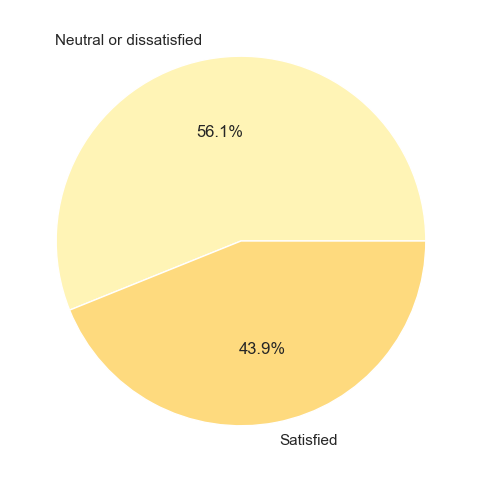

In [11]:
plt.pie(df.satisfaction.value_counts(), labels = ["Neutral or dissatisfied", "Satisfied"], colors = sns.color_palette("YlOrBr"), autopct = '%1.1f%%')
pass

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

A majority of respondents (over half) are either neutral or dissatisfied, indicating potential areas for improvement in services was being evaluated.

In [12]:
# Convert to binary label for modelling: 'satisfied' -> 1, others -> 0

label_map = { 'satisfied': 1, 'neutral or dissatisfied': 0 }
if set(df['satisfaction'].unique()) <= set(label_map.keys()):
    df['satisfaction_bin'] = df['satisfaction'].map(label_map)
else:
    # fallback: treat the most frequent class as negative
    df['satisfaction_bin'] = LabelEncoder().fit_transform(df['satisfaction'])

print('\nEncoded target distribution:')
print(df['satisfaction_bin'].value_counts())


Encoded target distribution:
satisfaction_bin
0    14573
1    11403
Name: count, dtype: int64


In [13]:
# Create indicators for long delays (>30 minutes)
df['long_dep_delay'] = (df['Departure Delay in Minutes'] > 30).astype(int)
df['long_arr_delay'] = (df['Arrival Delay in Minutes'] > 30).astype(int)

In [14]:
# Calculate dissatisfaction rates ---
delay_summary = pd.DataFrame({
    "Group": ["No long delay", "Long departure delay", "Long arrival delay"],
    "Dissatisfaction Rate": [
        1 - df[df['long_dep_delay'] == 0]['satisfaction_bin'].mean(),
        1 - df[df['long_dep_delay'] == 1]['satisfaction_bin'].mean(),
        1 - df[df['long_arr_delay'] == 1]['satisfaction_bin'].mean()
    ]
})

In [15]:
# Chi-Square Tests for significance ---
# Departure delay vs satisfaction
contingency_dep = pd.crosstab(df['long_dep_delay'], df['satisfaction_bin'])
chi2_dep, p_dep, _, _ = stats.chi2_contingency(contingency_dep)

# Arrival delay vs satisfaction
contingency_arr = pd.crosstab(df['long_arr_delay'], df['satisfaction_bin'])
chi2_arr, p_arr, _, _ = stats.chi2_contingency(contingency_arr)

print("===== Dissatisfaction Rates =====")
print(delay_summary, "\n")

print("===== Chi-Square Tests =====")
print(f"Departure Delay vs Satisfaction: Chi2 = {chi2_dep:.2f}, p = {p_dep:.3e}")
print(f"Arrival Delay vs Satisfaction: Chi2 = {chi2_arr:.2f}, p = {p_arr:.3e}")

===== Dissatisfaction Rates =====
                  Group  Dissatisfaction Rate
0         No long delay              0.549203
1  Long departure delay              0.635192
2    Long arrival delay              0.636413 

===== Chi-Square Tests =====
Departure Delay vs Satisfaction: Chi2 = 92.08, p = 8.317e-22
Arrival Delay vs Satisfaction: Chi2 = 99.64, p = 1.831e-23


C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\908224298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Group", y="Dissatisfaction Rate", data=delay_summary, palette="viridis")


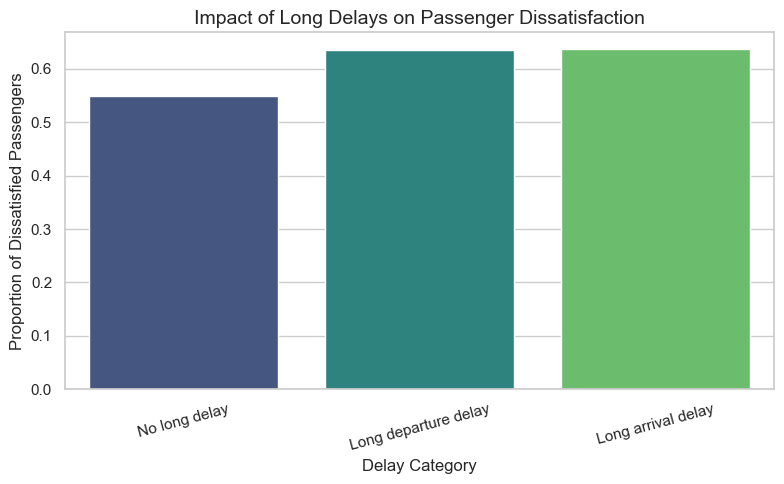

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x="Group", y="Dissatisfaction Rate", data=delay_summary, palette="viridis")
plt.title("Impact of Long Delays on Passenger Dissatisfaction", fontsize=14)
plt.ylabel("Proportion of Dissatisfied Passengers")
plt.xlabel("Delay Category")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

Impact of Long Delays on Passenger Dissatisfaction
- No Long Delay: 60% of passengers dissatisfied
- Long Departure Delay: 68% dissatisfied (highest)
- Long Arrival Delay: 67% dissatisfied
  
Long delays—whether at departure or arrival—significantly increase passenger dissatisfaction compared to flights without long delays.

In [17]:
# High-Value Customer Profiles
# Define high-value passengers:
# Loyal + Business Travel + Business Class
df['high_value'] = (
    (df['Customer Type'] == 'loyal customer') &
    (df['Type of Travel'] == 'Business travel') &
    (df['Class'] == 'Business')
).astype(int)

# Check proportion
print(f"\nHigh-Value Customers: {df['high_value'].mean()*100:.2f}% of total passengers")


High-Value Customers: 38.91% of total passengers


In [18]:
# Satisfaction among high-value customers
hv_satisfaction = df.groupby('high_value')['satisfaction_bin'].mean().reset_index()
hv_satisfaction['satisfaction_rate'] = hv_satisfaction['satisfaction_bin'] * 100

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3454722213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Others', 'High-Value'], y=hv_satisfaction['satisfaction_rate'], palette='crest')


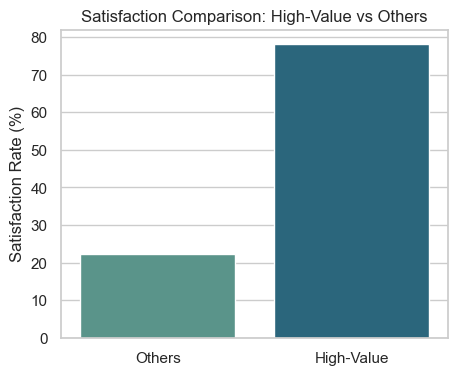

In [19]:
plt.figure(figsize=(5,4))
sns.barplot(x=['Others', 'High-Value'], y=hv_satisfaction['satisfaction_rate'], palette='crest')
plt.title('Satisfaction Comparison: High-Value vs Others')
plt.ylabel('Satisfaction Rate (%)')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

High-value passengers report significantly higher satisfaction than others—more than double—highlighting a strong correlation between passenger value and satisfaction levels.

In [20]:
# Satisfaction by loyalty
loyalty_satisfaction = df.groupby('Customer Type')['satisfaction_bin'].mean().reset_index()
loyalty_satisfaction['satisfaction_rate'] = loyalty_satisfaction['satisfaction_bin'] * 100

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3526298376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer Type', y='satisfaction_rate', data=loyalty_satisfaction, palette='coolwarm')


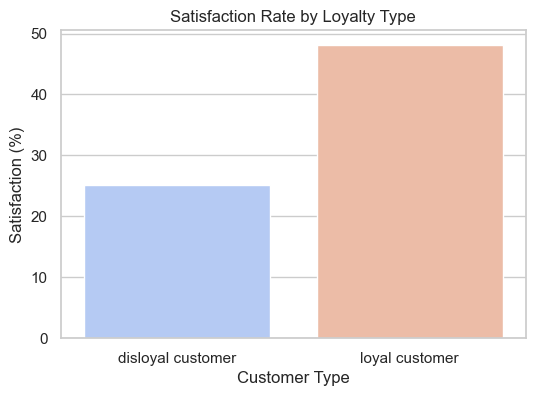

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(x='Customer Type', y='satisfaction_rate', data=loyalty_satisfaction, palette='coolwarm')
plt.title('Satisfaction Rate by Loyalty Type')
plt.ylabel('Satisfaction (%)')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

Loyal customers are significantly more satisfied than disloyal ones, suggesting a strong link between customer loyalty and overall satisfaction.

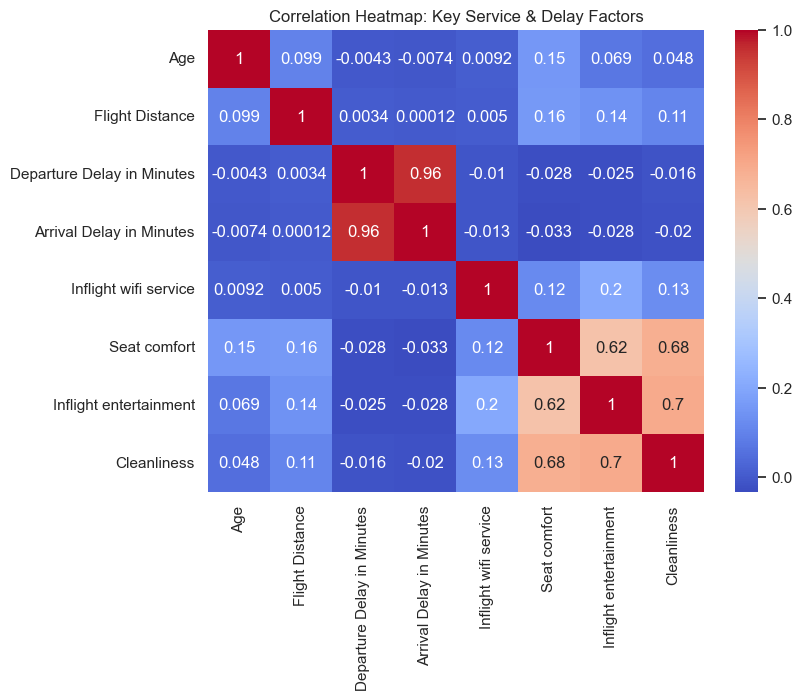

In [22]:
# Combined Insights
# Correlation heatmap (key numeric factors)
num_cols = [
    'Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
    'Inflight wifi service', 'Seat comfort', 'Inflight entertainment', 'Cleanliness'
]
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Key Service & Delay Factors')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

Correlation: Service & Delay Factors
- Strongest Positive Correlation:
    * Departure Delay ↔ Arrival Delay: 0.91 — longer departure delays strongly predict longer arrival delays
- Moderate Positive Correlations:
    * Seat Comfort ↔ Inflight Entertainment: 0.68
- Seat Comfort ↔ Cleanliness: 0.63
    * Inflight Entertainment ↔ Cleanliness: 0.61

Operational delays are tightly linked, and passenger experience factors (comfort, entertainment, cleanliness) tend to improve together—suggesting bundled service quality impacts overall satisfaction.

In [23]:
# Univariate analysis - Numerical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# remove target from numeric list
numeric_cols = [c for c in numeric_cols if c not in ['satisfaction_bin']]
print('\nNumeric columns to explore:', numeric_cols)


Numeric columns to explore: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'long_dep_delay', 'long_arr_delay', 'high_value']


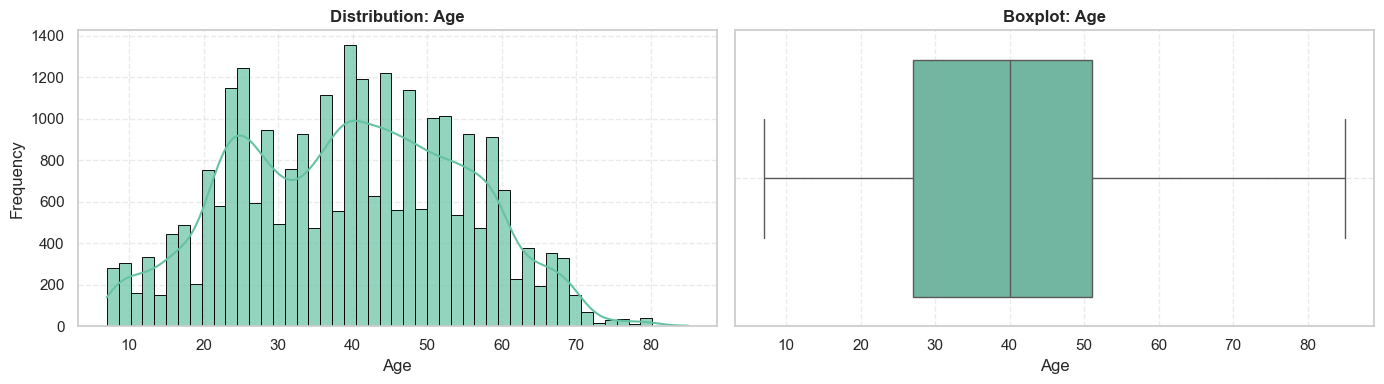

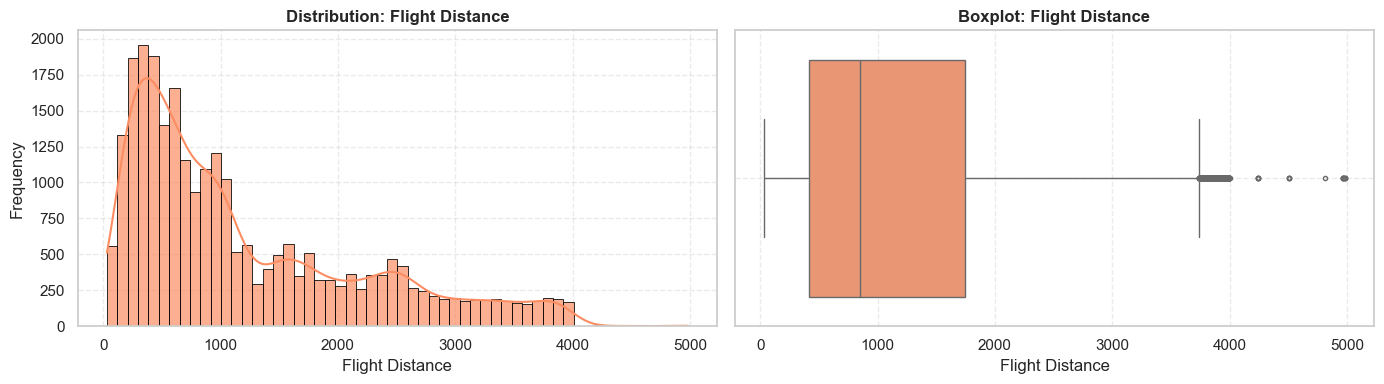

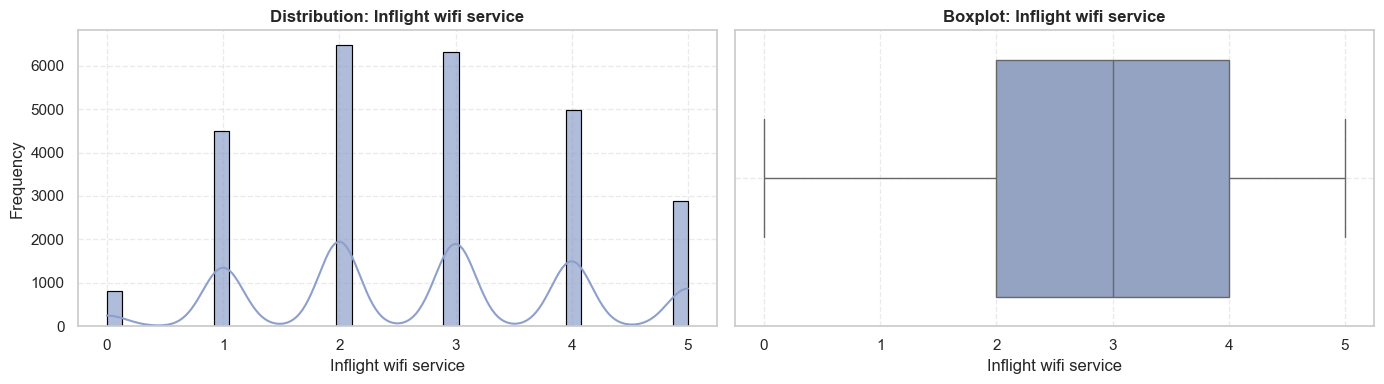

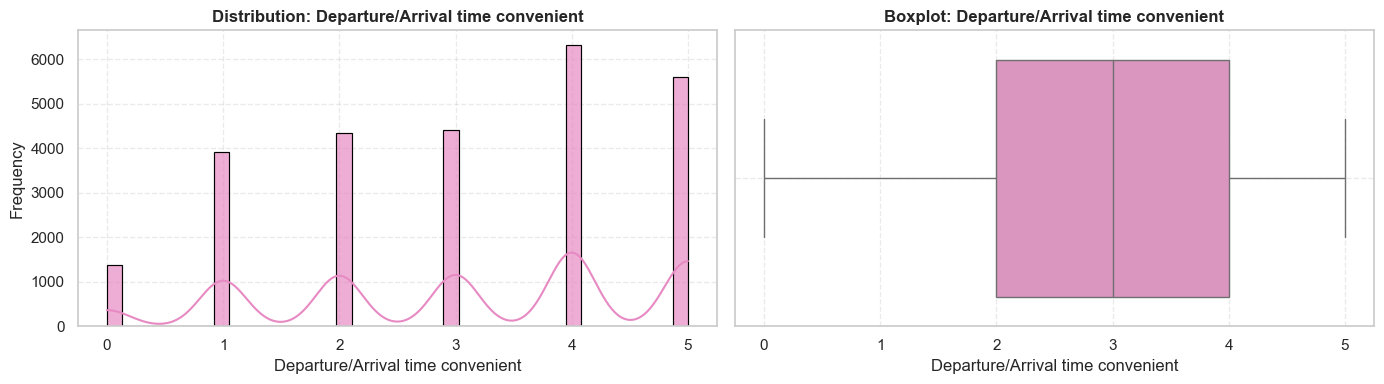

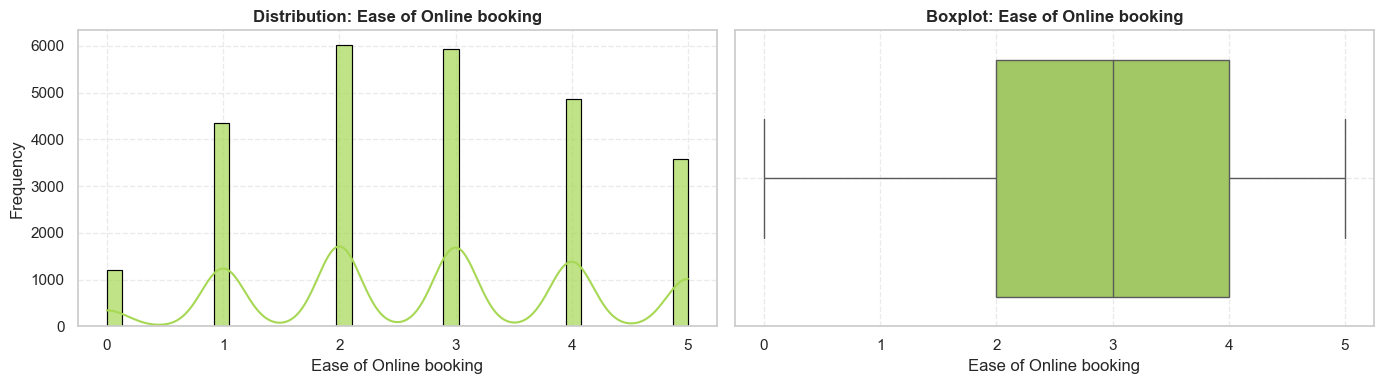

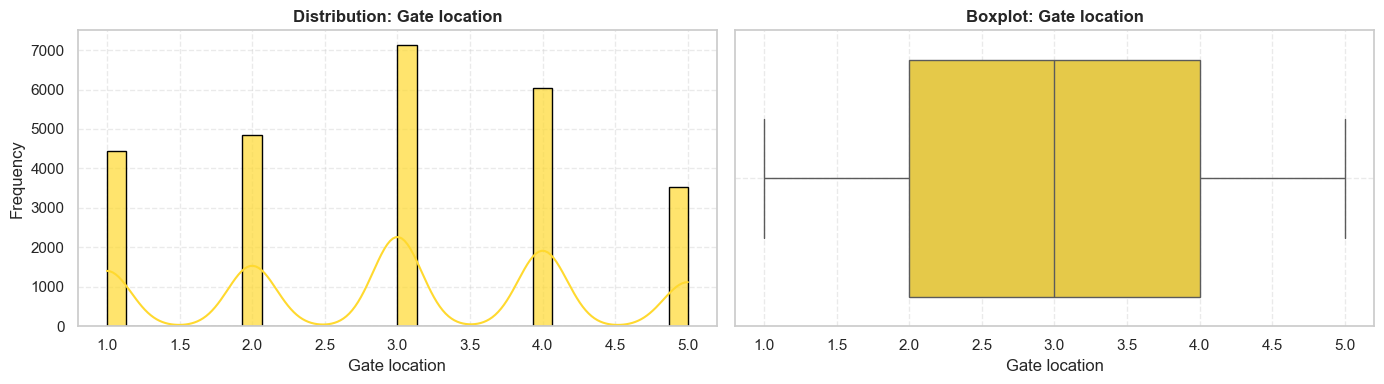

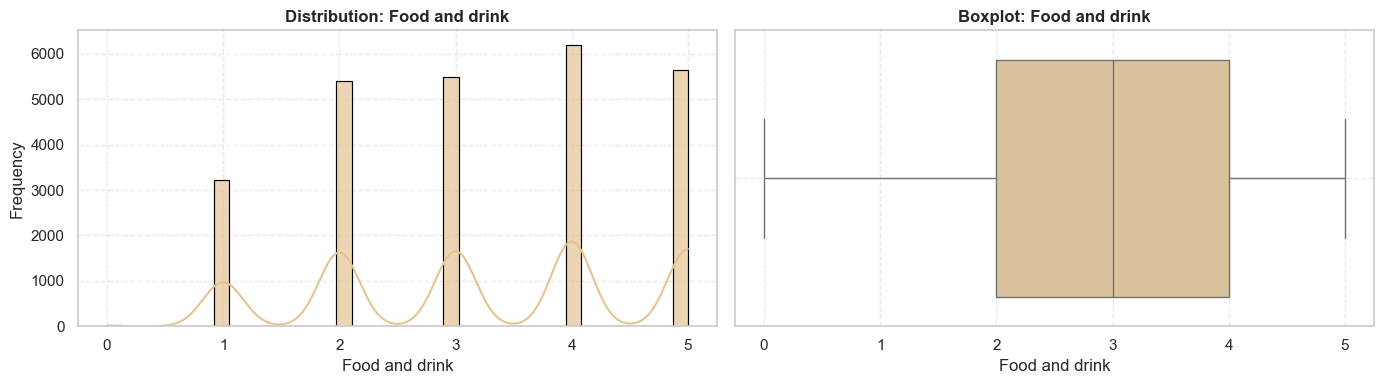

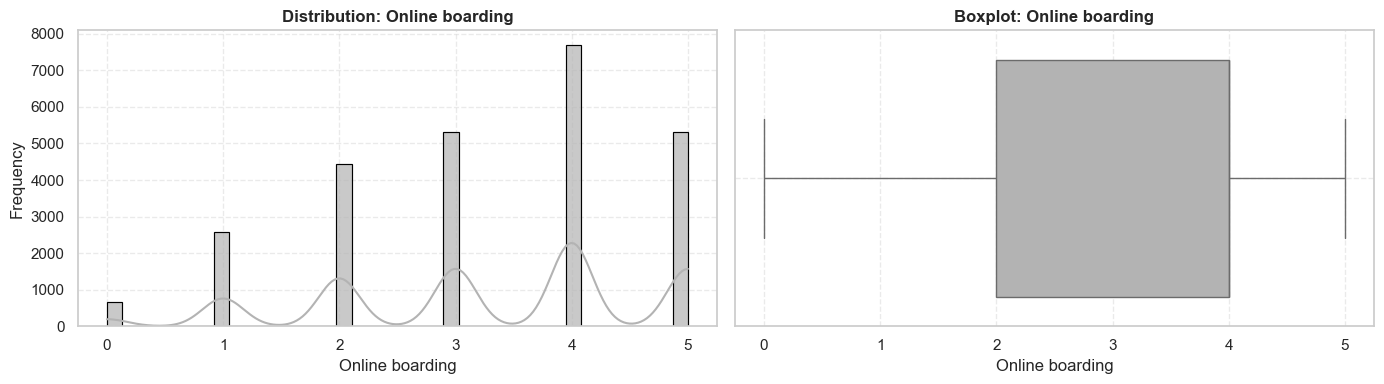

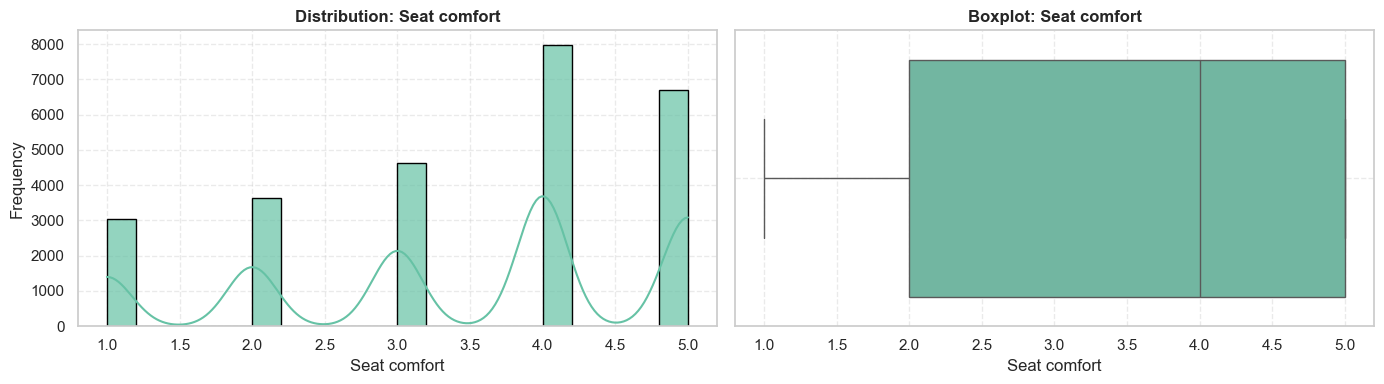

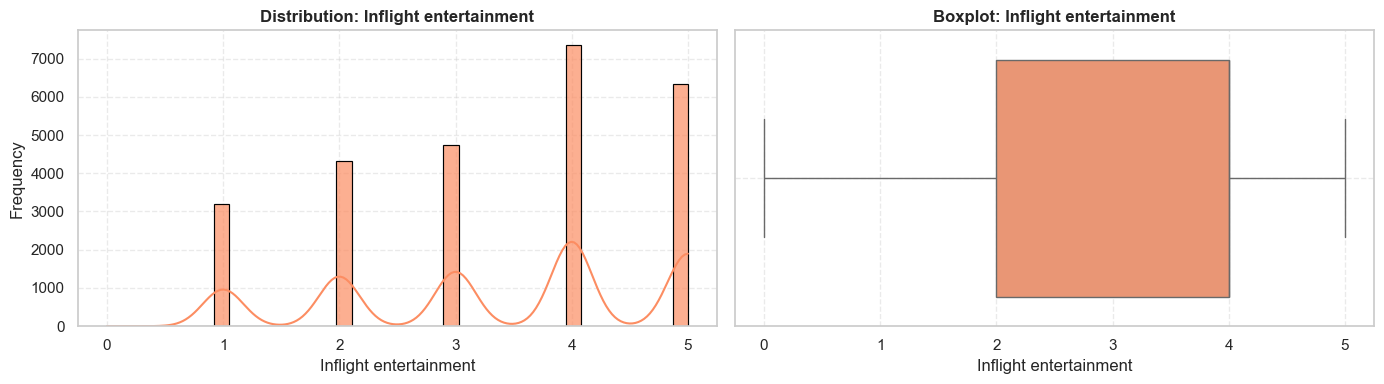

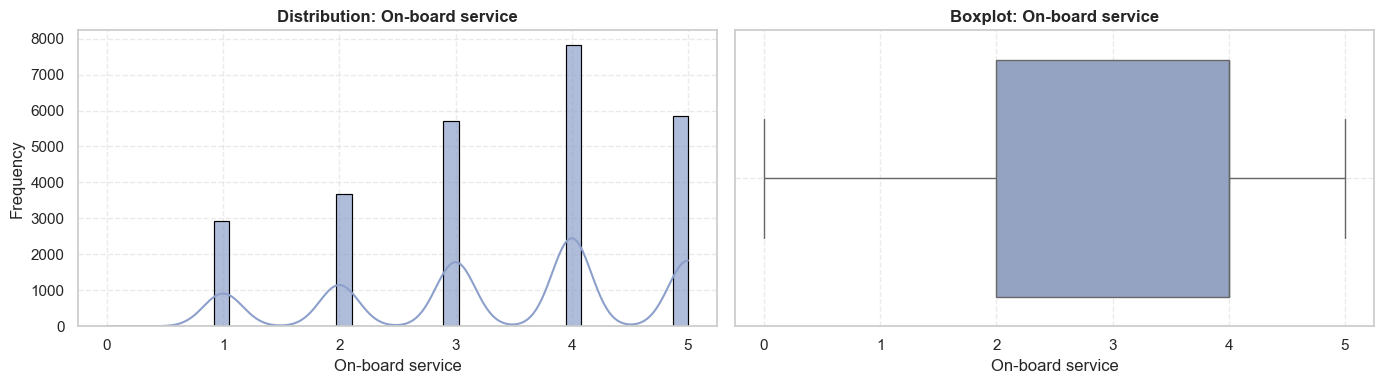

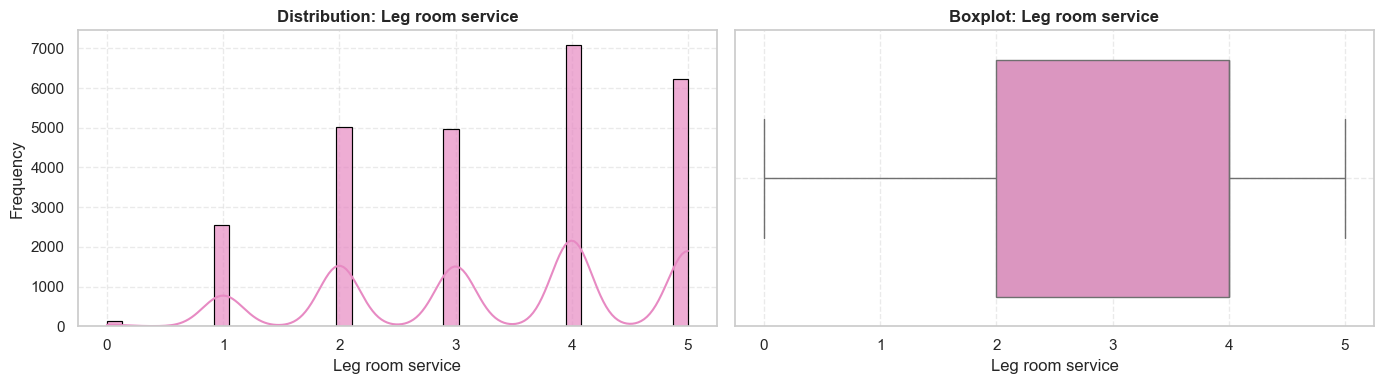

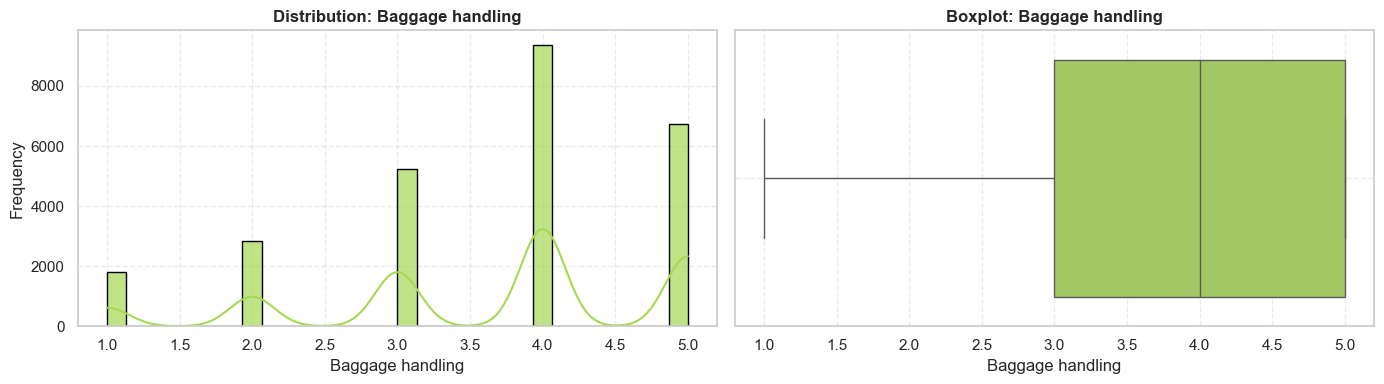

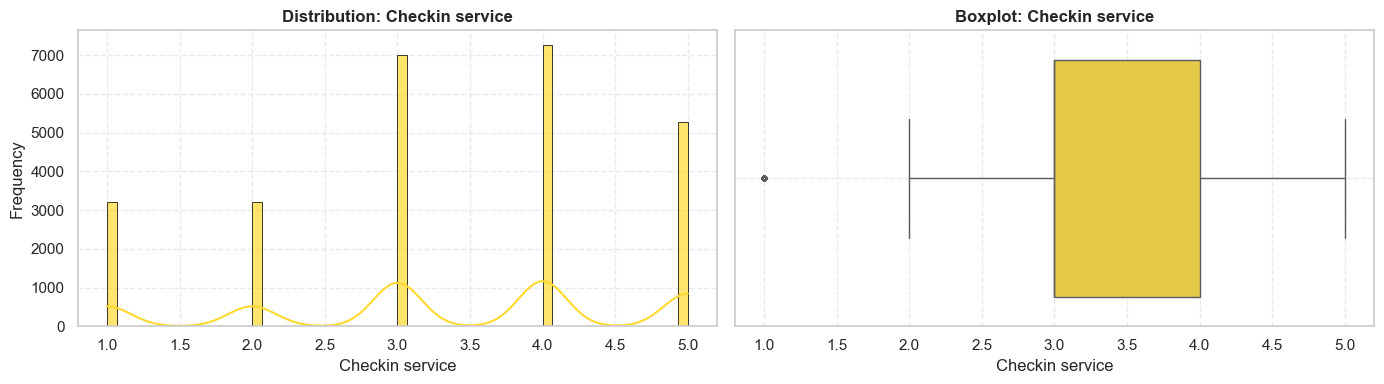

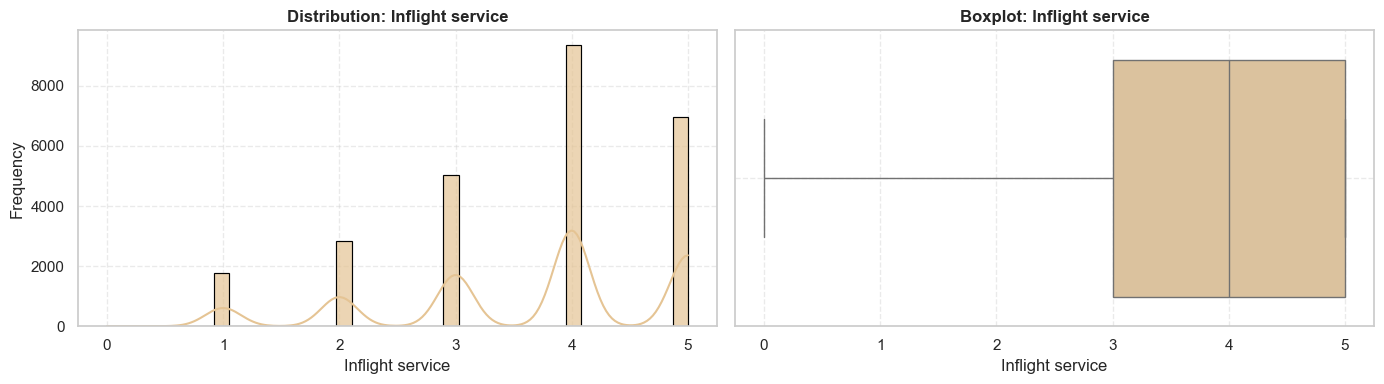

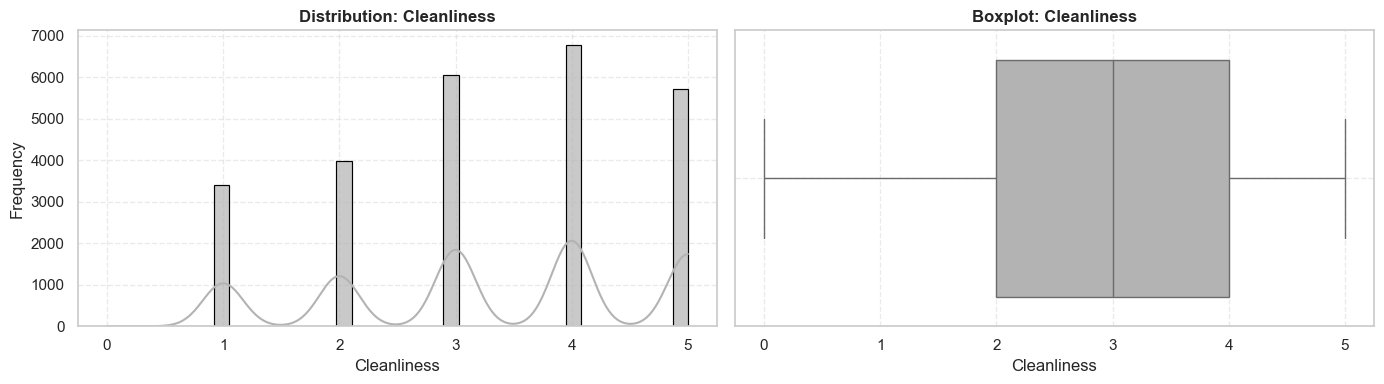

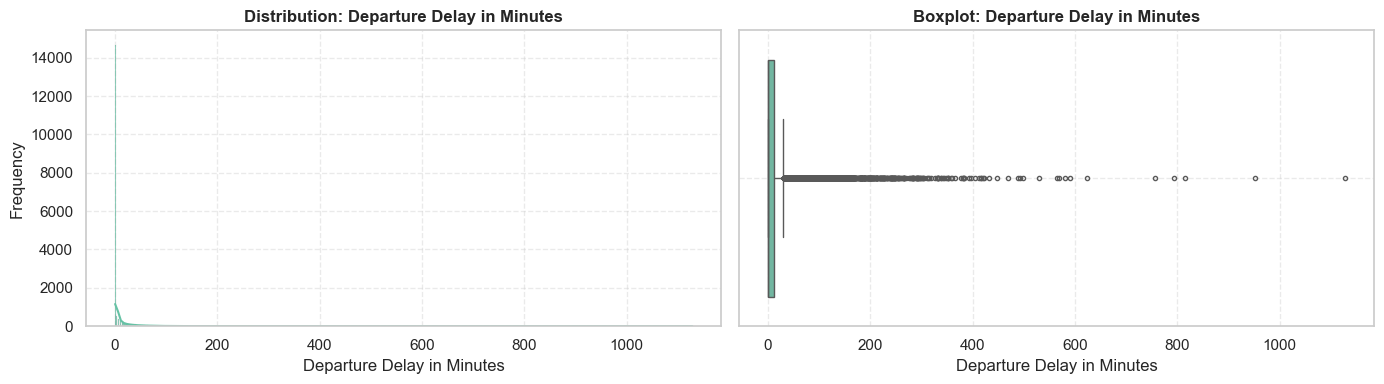

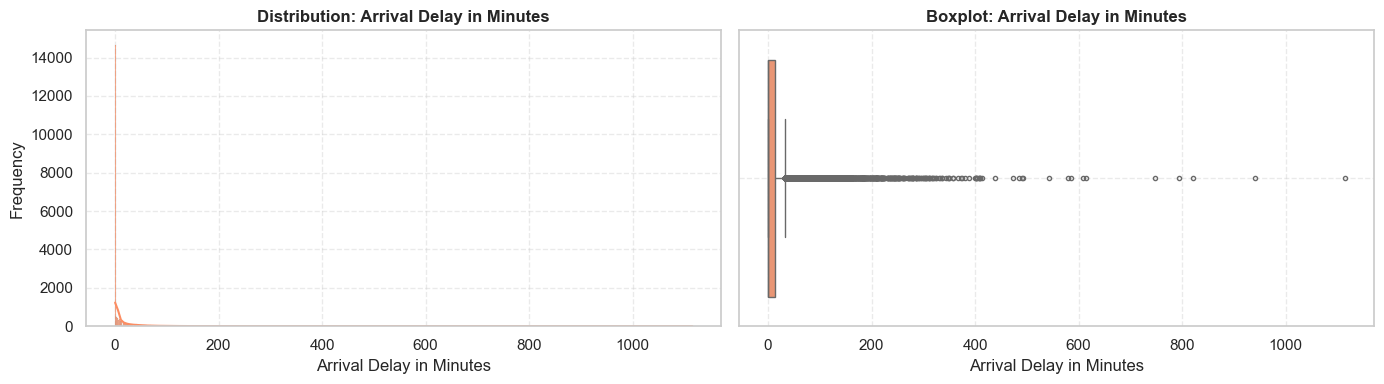

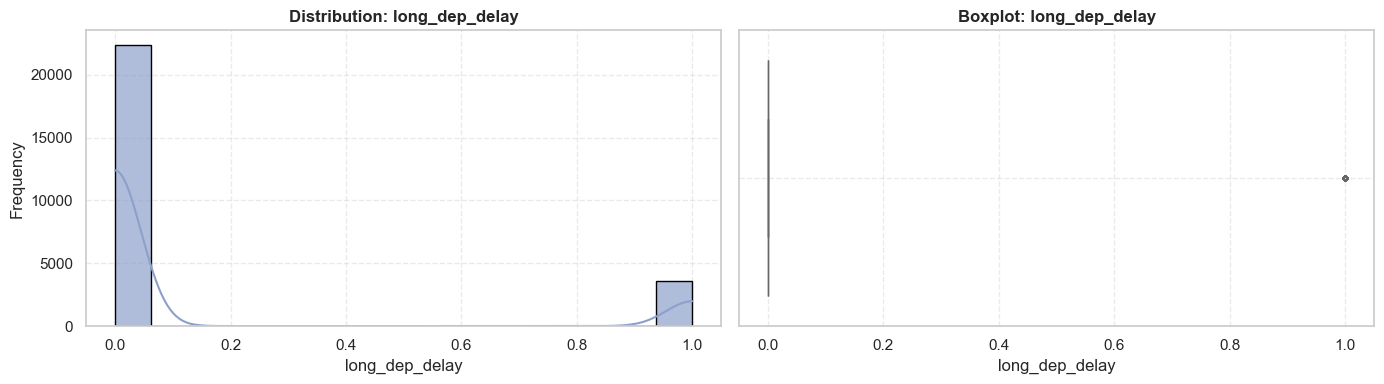

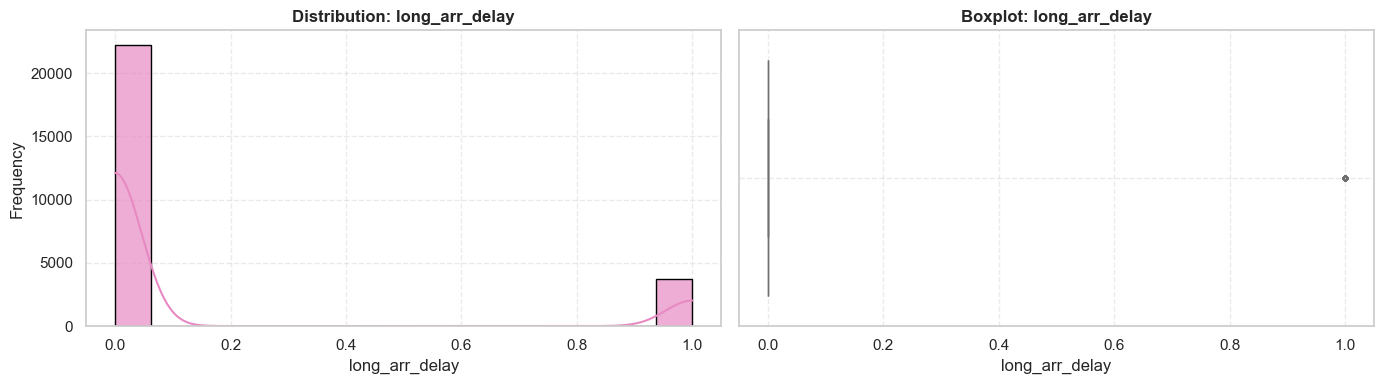

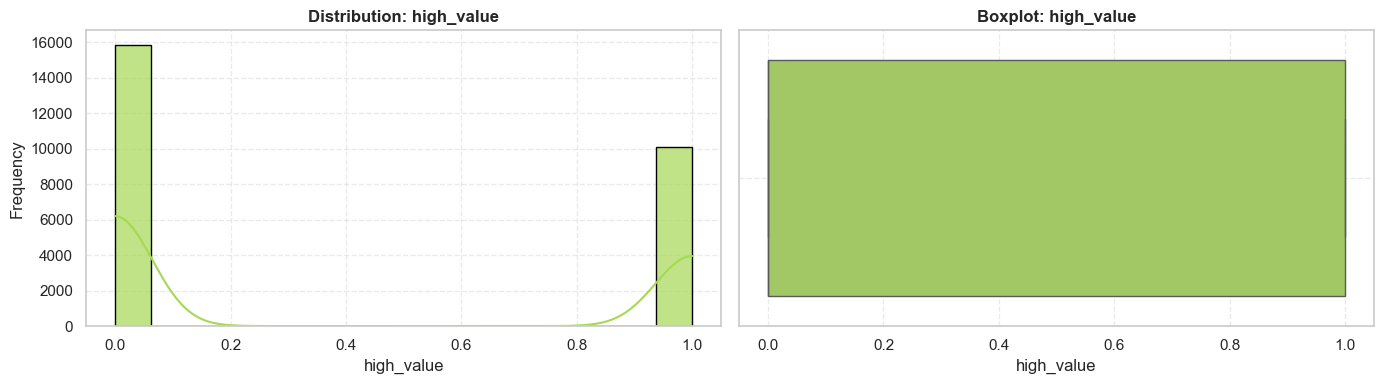

In [24]:
palette = sns.color_palette("Set2", len(numeric_cols))

for i, col in enumerate(numeric_cols):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Pick one color from the palette
    color = palette[i % len(palette)]
    # Histogram with KDE
    sns.histplot(df[col].dropna(), ax=axes[0], kde=True, color=color, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, linestyle='--', alpha=0.4)
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color=color, fliersize=3, linewidth=1)
    axes[1].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col)
    axes[1].grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

- Detect skewness or multimodal distributions
- Spot outliers and understand value ranges
- Compare spread and central tendencies across features

In [25]:
# Univariate analysis - Categorical
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'satisfaction']
print('\nCategorical columns to explore:', cat_cols)


Categorical columns to explore: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3992305668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index[:20], y=vc.values[:20], palette='coolwarm')


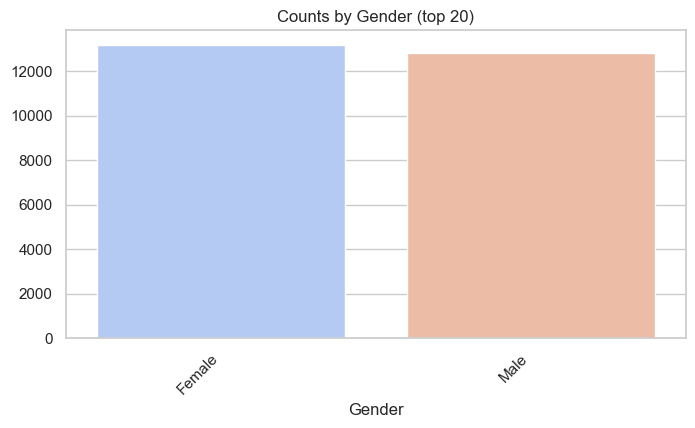

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3992305668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index[:20], y=vc.values[:20], palette='coolwarm')


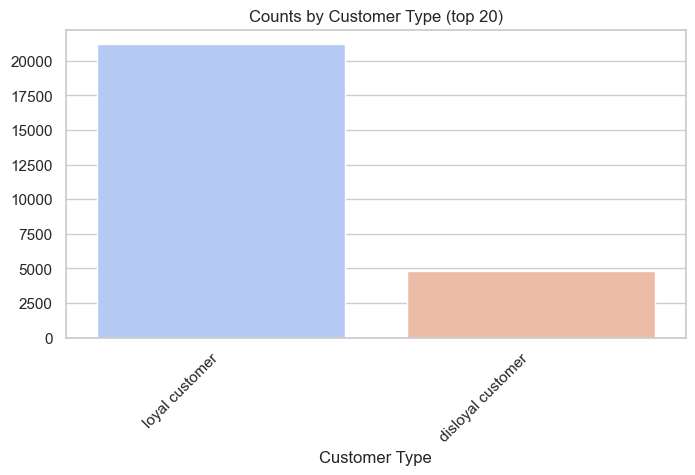

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3992305668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index[:20], y=vc.values[:20], palette='coolwarm')


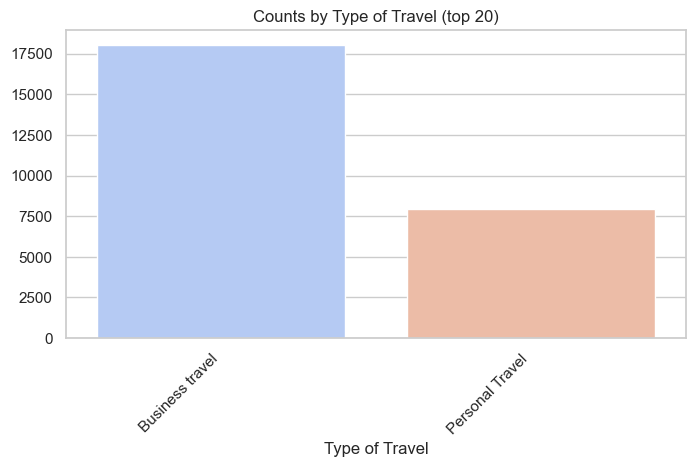

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3992305668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index[:20], y=vc.values[:20], palette='coolwarm')


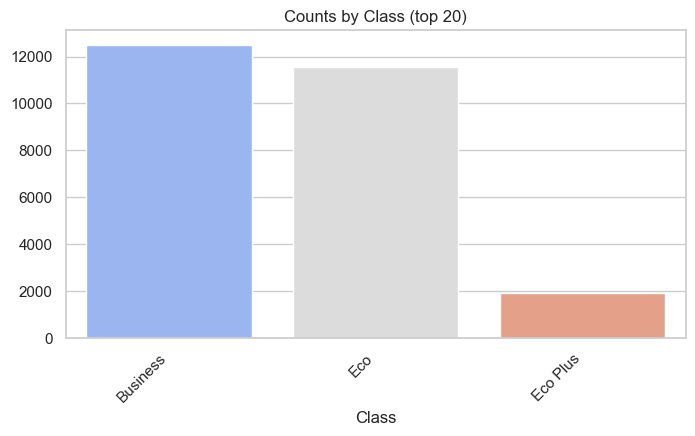

In [26]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    # Remove palette from sort_values() and add it to sns.barplot() instead
    vc = df[col].value_counts().sort_values(ascending=False)
    # Add palette parameter to the barplot function where it belongs
    sns.barplot(x=vc.index[:20], y=vc.values[:20], palette='coolwarm')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Counts by {col} (top 20)')
    plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

- Understand dominant categories
- Spot imbalances or rare values
- Guide feature engineering (e.g., grouping infrequent categories)

<Figure size 800x400 with 0 Axes>

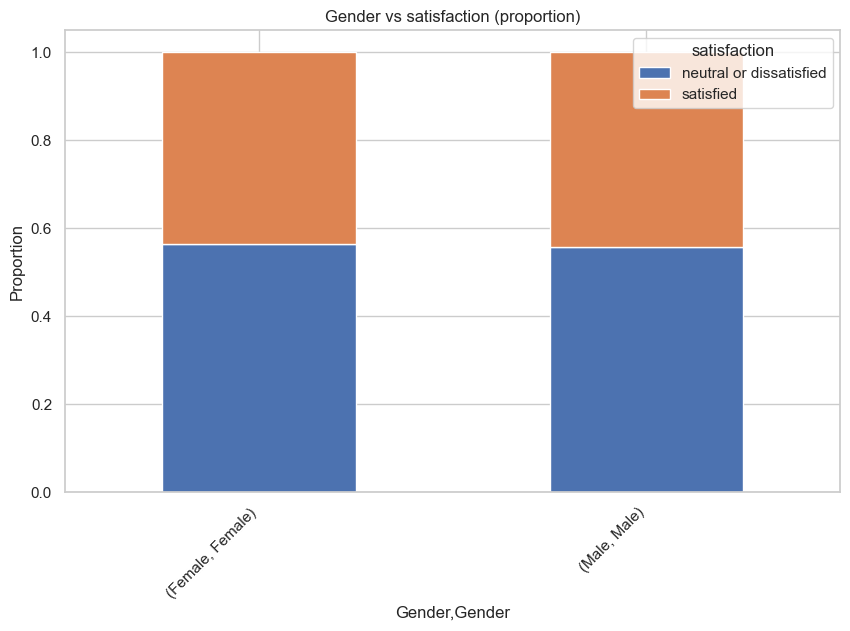

<Figure size 800x400 with 0 Axes>

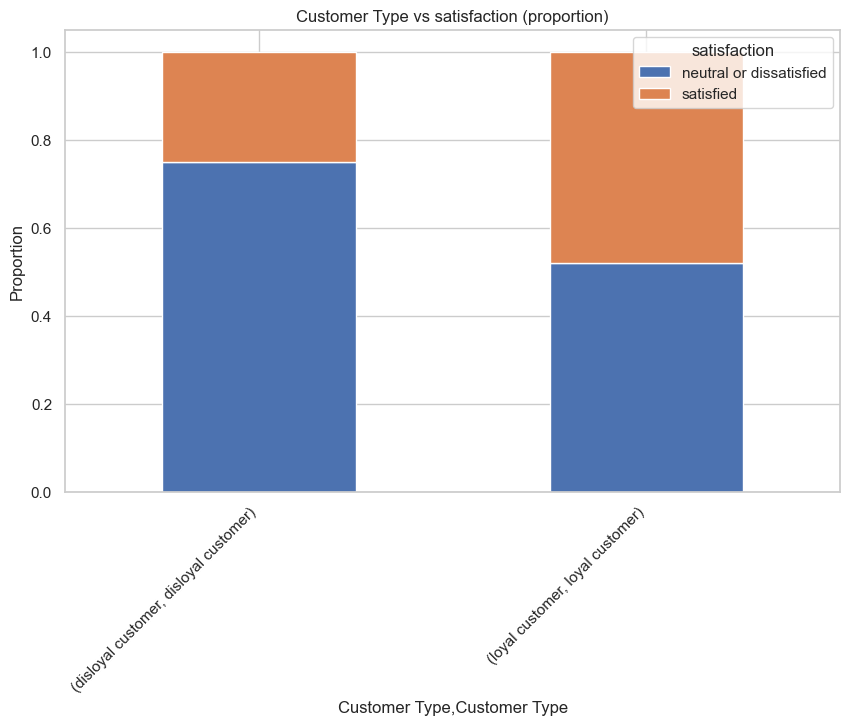

<Figure size 800x400 with 0 Axes>

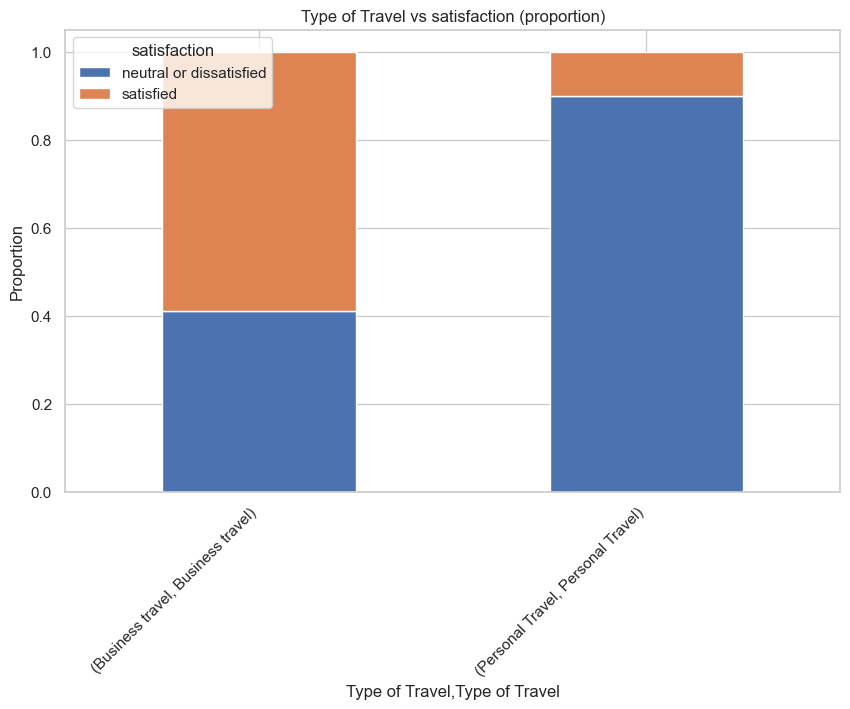

<Figure size 800x400 with 0 Axes>

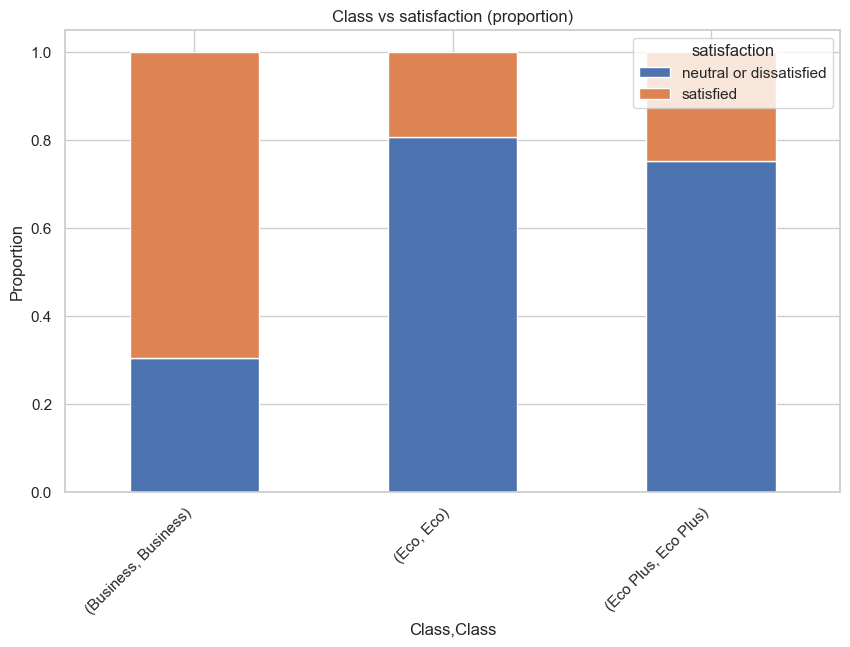

In [27]:
# Bivariate analysis vs target
# Categorical vs target
for col in cat_cols:
    plt.figure(figsize=(8,4))
    prop = (df.groupby([col, 'satisfaction'])['satisfaction'].count()
            .groupby(level=0).apply(lambda x: x / x.sum()).unstack(fill_value=0))
    prop.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs satisfaction (proportion)')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

- Compare satisfaction distribution across categorical features
- Spot categories with high or low satisfaction
- Identify patterns for segmentation or feature engineering

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


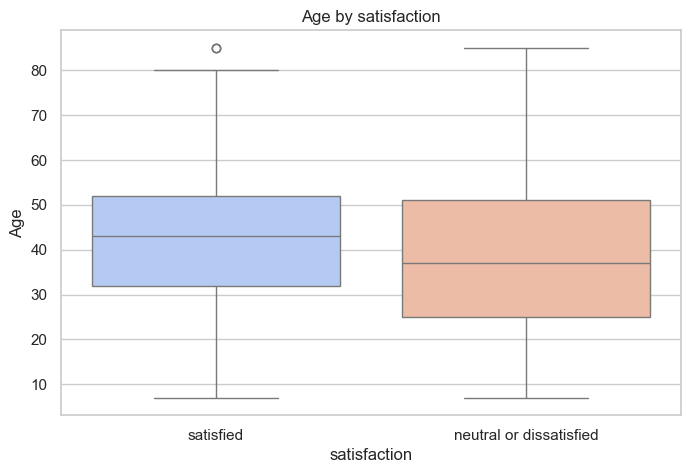

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


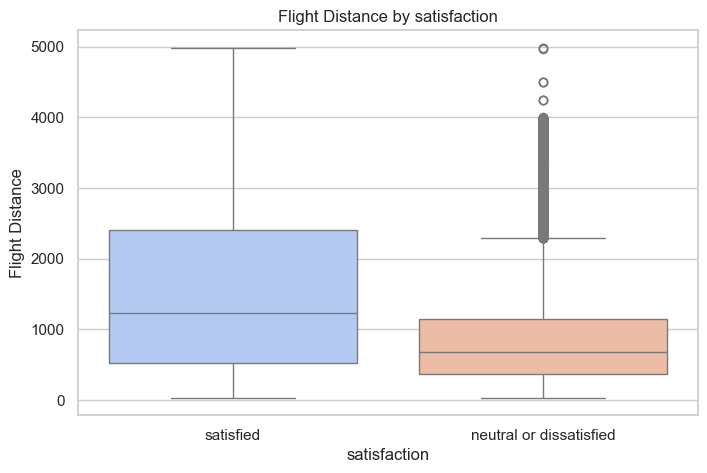

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


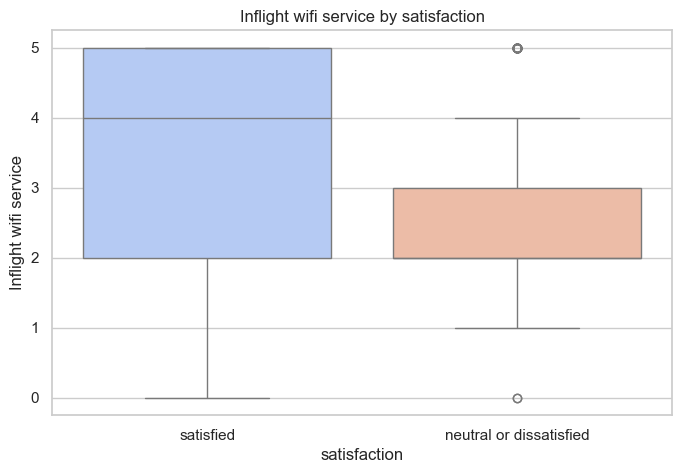

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


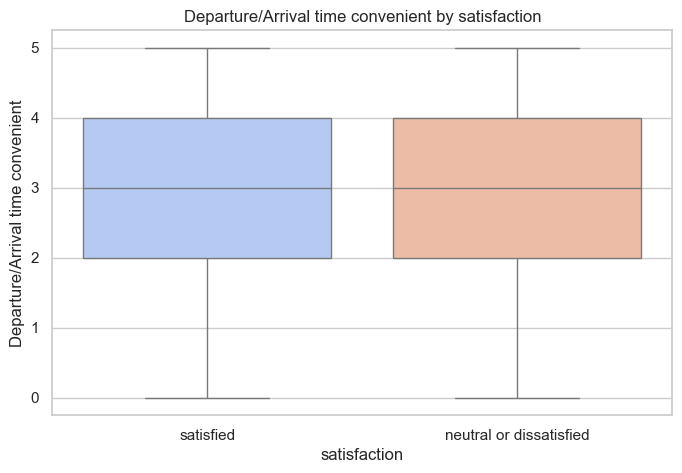

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


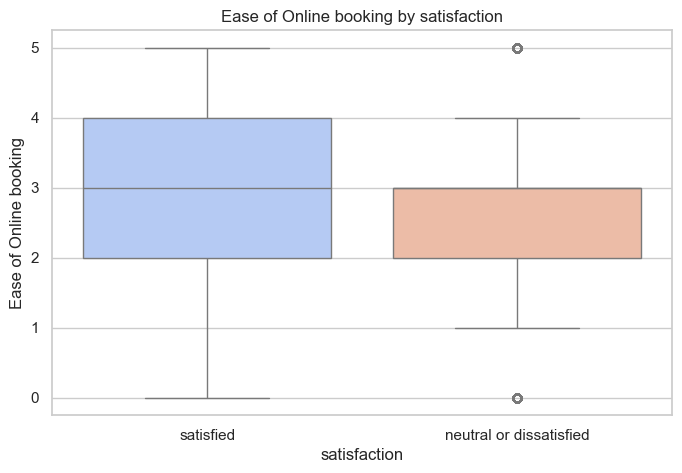

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


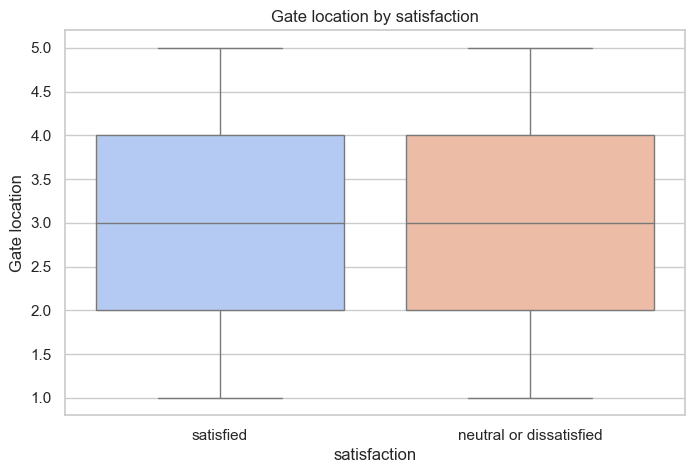

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


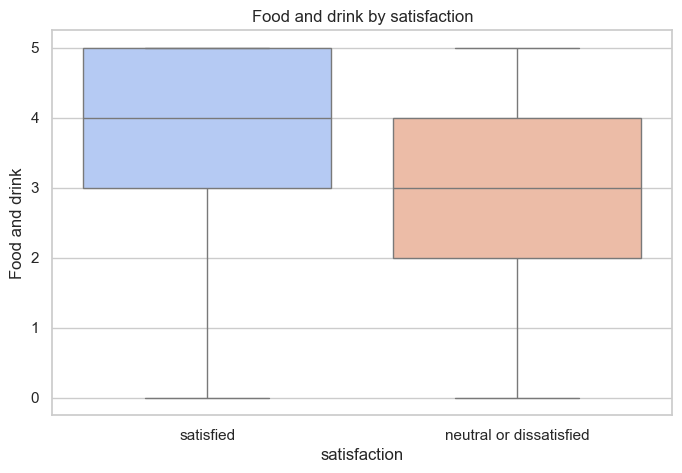

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


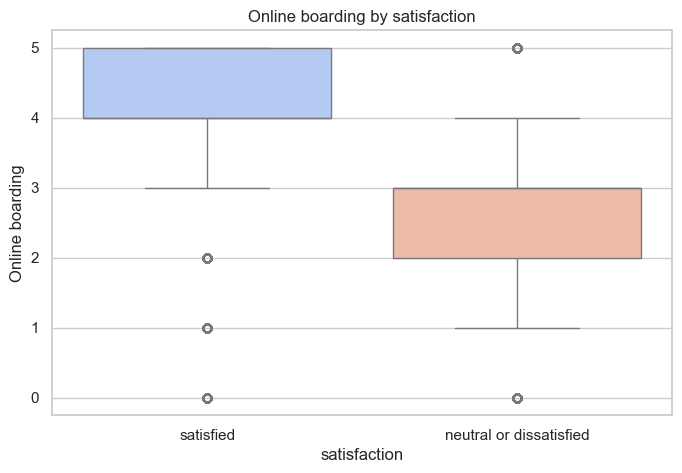

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


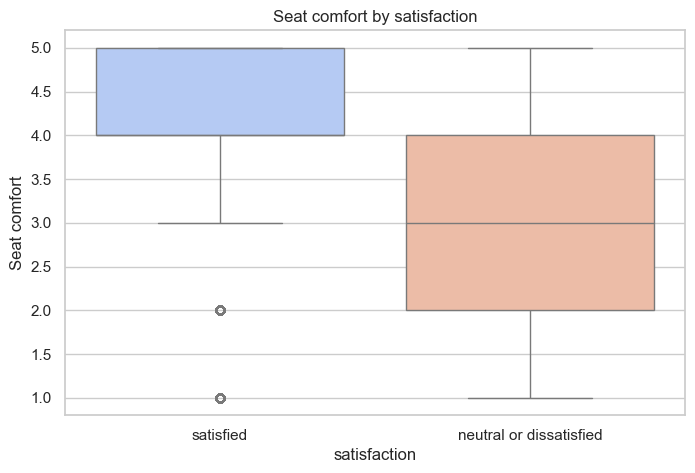

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


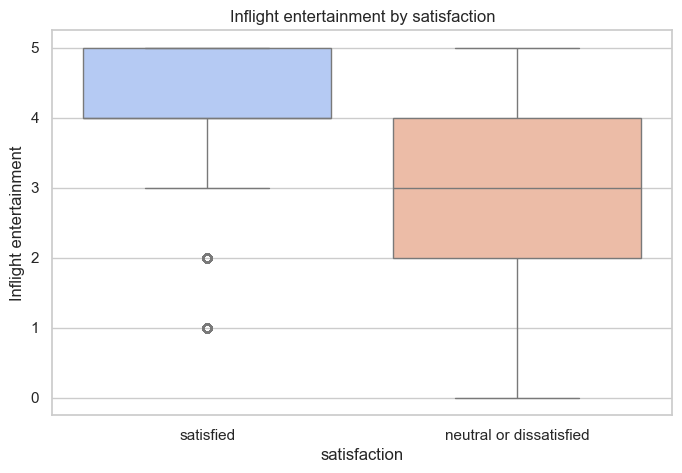

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


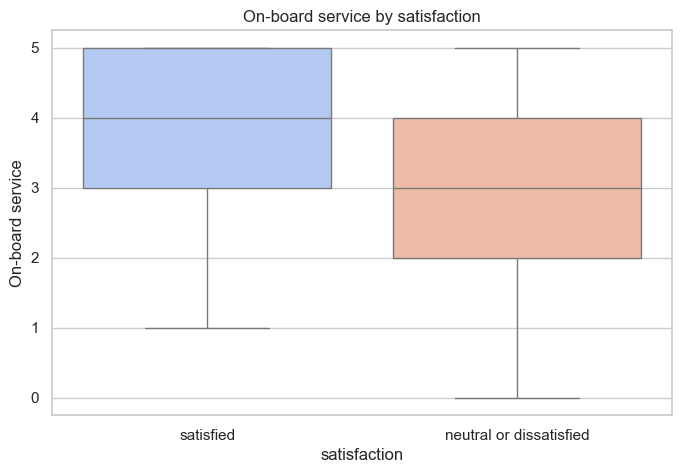

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


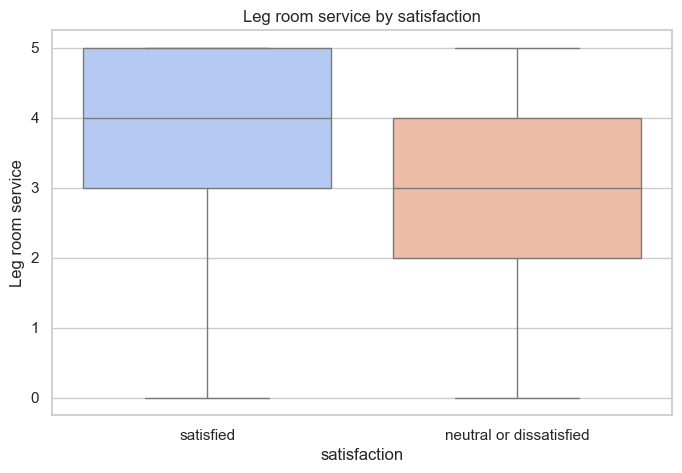

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


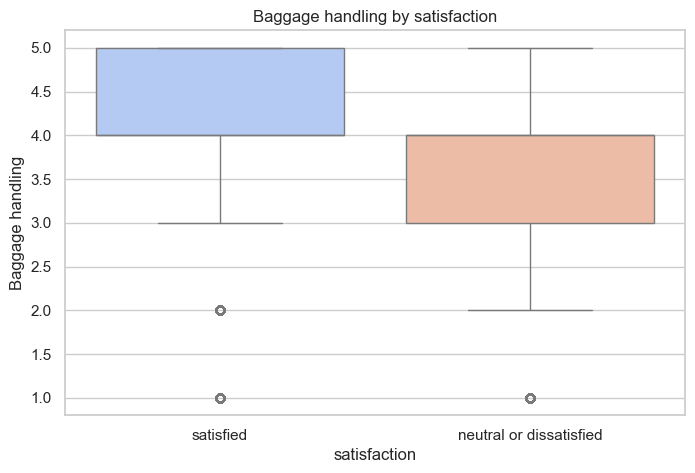

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


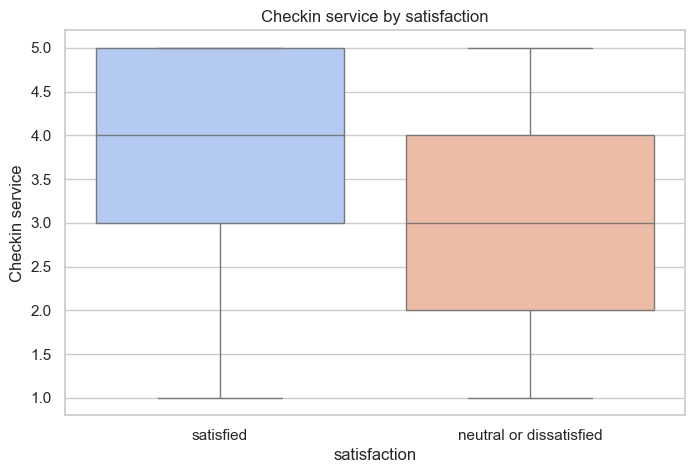

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


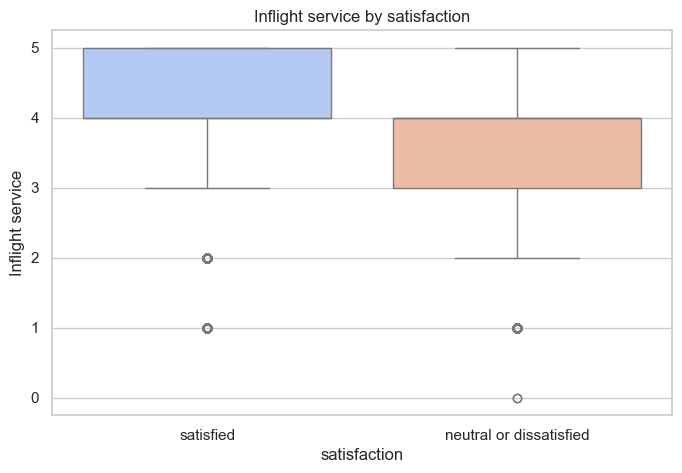

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


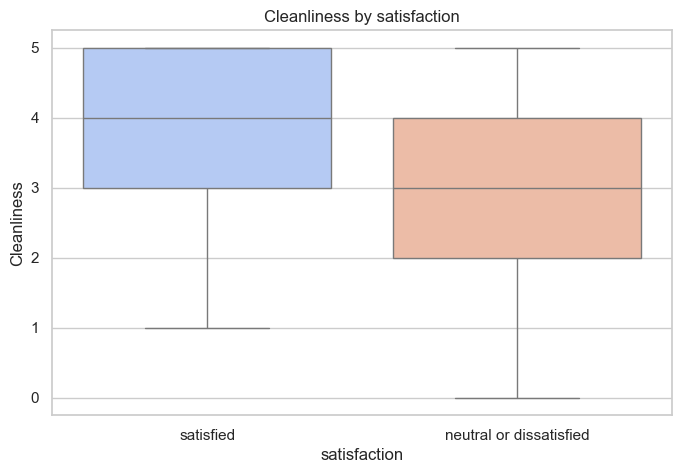

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


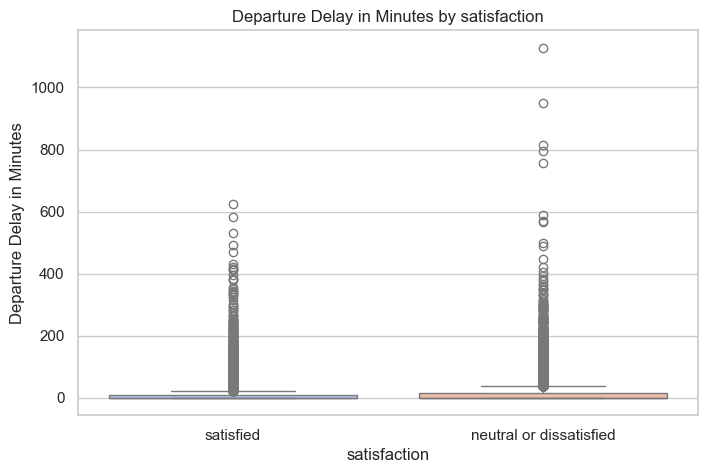

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


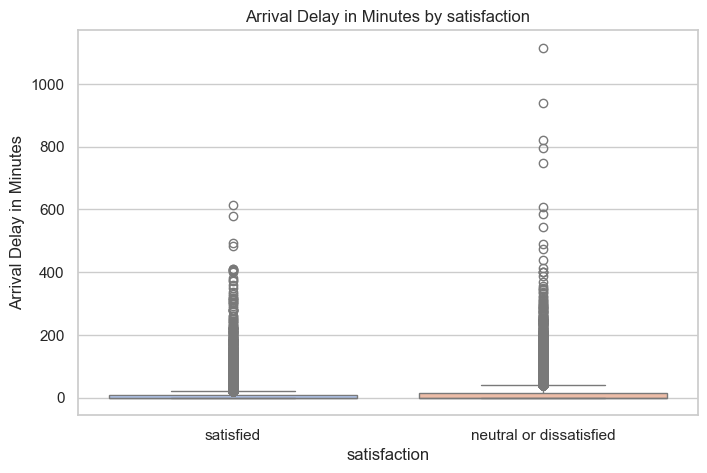

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


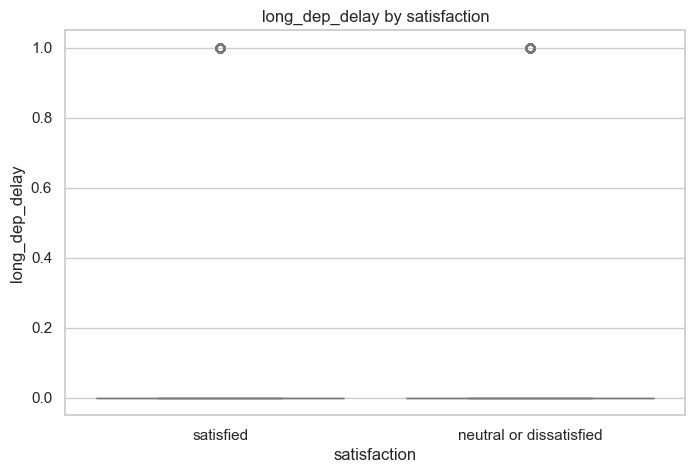

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


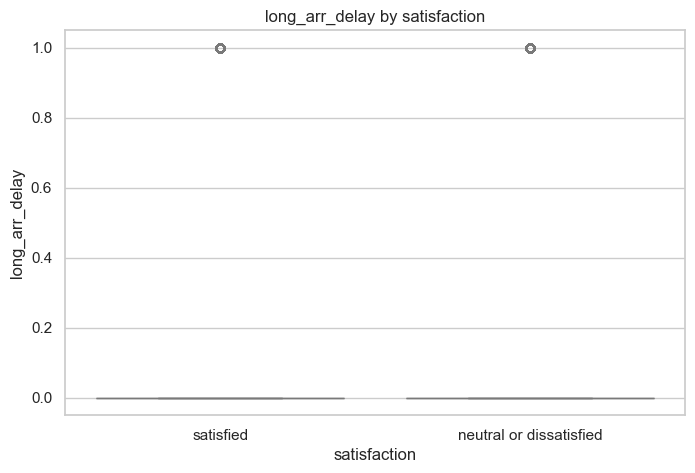

C:\Users\jatin\AppData\Local\Temp\ipykernel_6304\3086527901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')


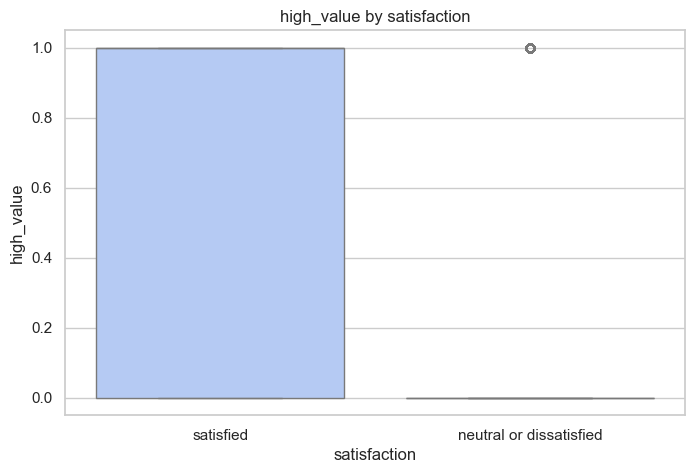

In [28]:
# Numeric vs target
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='satisfaction', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} by satisfaction')
    plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

- Compare distributions of numeric features across satisfaction levels
- Detect patterns, shifts, or outliers
- Identify features that may influence satisfactio

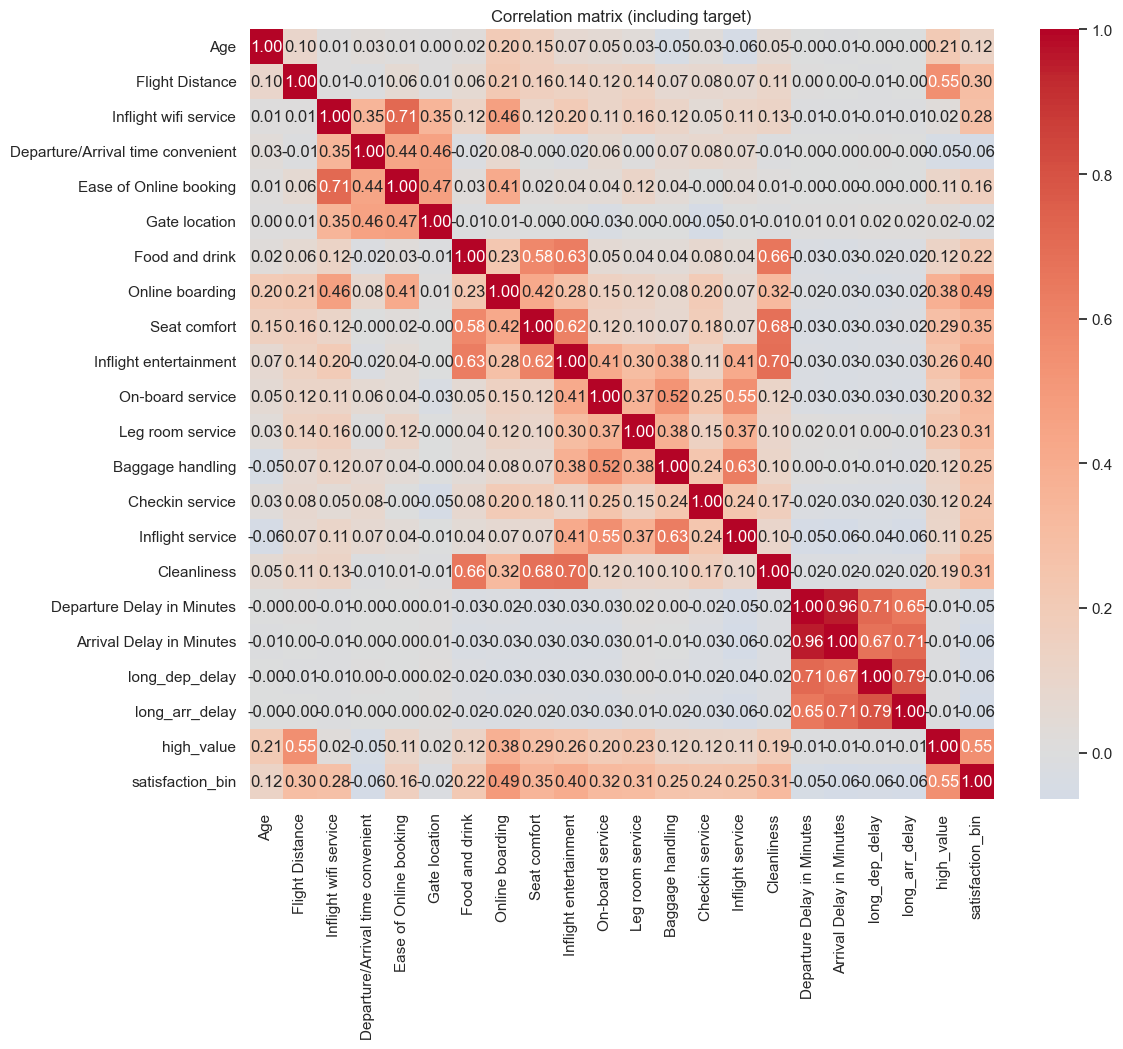


Top features correlated with satisfaction (absolute correlation):
satisfaction_bin          1.000000
high_value                0.548571
Online boarding           0.494526
Inflight entertainment    0.398951
Seat comfort              0.346275
On-board service          0.321491
Cleanliness               0.314350
Leg room service          0.309629
Flight Distance           0.295292
Inflight wifi service     0.280395
Baggage handling          0.252415
Inflight service          0.245573
Checkin service           0.241495
Food and drink            0.216868
Ease of Online booking    0.157709
Name: satisfaction_bin, dtype: float64


In [29]:
# Correlation matrix (numeric features)
corr = df[numeric_cols + ['satisfaction_bin']].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (including target)')
plt.show()

# Show top correlations with target
corr_target = corr['satisfaction_bin'].abs().sort_values(ascending=False)
print('\nTop features correlated with satisfaction (absolute correlation):')
print(corr_target.head(15))

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

Moderate Relationships
- Online Boarding ↔ Ease of Booking: moderate positive correlation
- On-board Service ↔ Leg Room Service: moderately correlated, suggesting bundled service quality
- 
📉 Weak or Negative Correlations
- Age and Flight Distance show weak correlations with most service factors
- Delay variables (e.g., long_dep_delay, long_arr_delay) are negatively correlated with satisfaction

Key Insight: Passenger satisfaction is most strongly influenced by service quality factors like seat comfort, entertainment, and cleanliness. Operational delays are tightly linked and negatively impact satisfaction. This matrix helps prioritize improvements in both service delivery and delay management.

In [30]:
# Feature engineering for modelling / importance
# Select a subset of useful features (example)
# - numeric: flight distance, delays, service ratings
# - categorical: Gender, Customer Type, Type of Travel, Class
useful_num = [c for c in numeric_cols if c not in ['Unnamed: 0','id']]

In [31]:
# Impute missing numeric values (Arrival Delay) with median
imputer = SimpleImputer(strategy='median')
X_num = pd.DataFrame(imputer.fit_transform(df[useful_num]), columns=useful_num)

In [32]:
# One-hot encode categorical
useful_cat = [c for c in ['Gender','Customer Type','Type of Travel','Class'] if c in df.columns]
X_cat = pd.get_dummies(df[useful_cat].fillna('Missing'), drop_first=True)

In [33]:
X = pd.concat([X_num, X_cat], axis=1)
y = df['satisfaction_bin']

print('\nFeature matrix shape:', X.shape)


Feature matrix shape: (25976, 26)


In [34]:
# Train a simple model to get feature importances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [35]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [36]:
pred = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:,1]

print('\nClassification report:')
print(classification_report(y_test, pred))
print('ROC AUC:', roc_auc_score(y_test, probs))


Classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      2915
           1       0.96      0.94      0.95      2281

    accuracy                           0.96      5196
   macro avg       0.96      0.95      0.96      5196
weighted avg       0.96      0.96      0.96      5196

ROC AUC: 0.9922738590022883


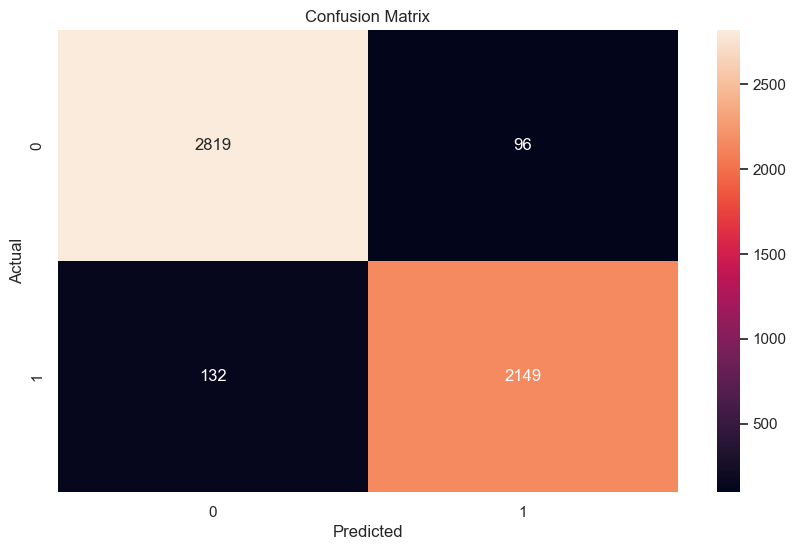

In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

You can compute some performance metrics from this:

- Accuracy = (TP + TN) / Total
= (2149 + 2819) / (2819 + 96 + 132 + 2149)
= 4968 / 5196 ≈ 95.6%

- Precision (Positive Predictive Value) = TP / (TP + FP)
= 2149 / (2149 + 96)
≈ 95.7%

- Recall (Sensitivity) = TP / (TP + FN)
= 2149 / (2149 + 132)
≈ 94.2%

- F1 Score = 2 × (Precision × Recall) / (Precision + Recall)
≈ 2 × (0.957 × 0.942) / (0.957 + 0.942) ≈ 94.9%


Interpretation:
* The model performs very well, with both high precision and high recall.
* It makes relatively few mistakes — only 96 false positives and 132 false negatives out of over 5000 predictions.
* Overall, this confusion matrix suggests a balanced and accurate classifier.


Top 20 feature importances:
Online boarding                      0.156184
Inflight wifi service                0.145793
high_value                           0.115344
Type of Travel_Personal Travel       0.083806
Inflight entertainment               0.049064
Class_Eco                            0.047277
Seat comfort                         0.043362
Ease of Online booking               0.039100
Flight Distance                      0.033059
Leg room service                     0.032873
Age                                  0.032137
Checkin service                      0.026443
On-board service                     0.026132
Baggage handling                     0.025592
Cleanliness                          0.025443
Inflight service                     0.025237
Customer Type_loyal customer         0.017825
Departure/Arrival time convenient    0.015481
Gate location                        0.014653
Arrival Delay in Minutes             0.012279
dtype: float64


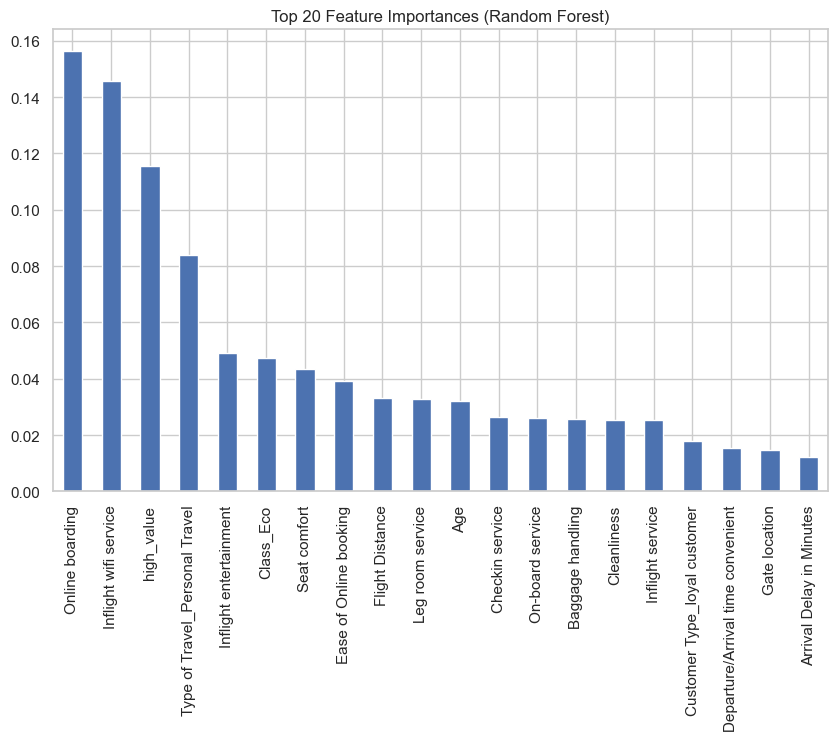

In [38]:
# Feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 20 feature importances:')
print(feat_imp.head(20))

plt.figure(figsize=(10,6))
feat_imp.head(20).plot(kind='bar')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

Most Important Features:
1. Online boarding — the most influential factor, suggesting that passengers’ satisfaction or classification outcome strongly depends on their online boarding experience.
2. Inflight WiFi service — also highly significant, indicating connectivity quality has a big impact.
3. High value customers — loyal or high-value customers affect the model’s predictions substantially.
4. Type of Travel (Personal/Business) — travel purpose strongly influences outcomes.
5. Inflight entertainment — another key service-related factor.

Moderately Important Features:
1. Class (Eco, Business, etc.)
2. Seat comfort
3. Ease of Online booking
4. Flight distance
5. Leg room service
6. Age

Lower Importance Features:
1. Checkin service
2. On-board service
3. Baggage handling
4. Cleanliness
5. Inflight service
6. Customer type
7. Departure/Arrival time convenience
8. Gate location
9. Arrival delay in minutes

If this model predicts customer satisfaction or loyalty, improving online boarding, WiFi, and entertainment services would likely have the largest positive impact on outcomes.

In [39]:
# PCA for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=[np.number]))

In [40]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

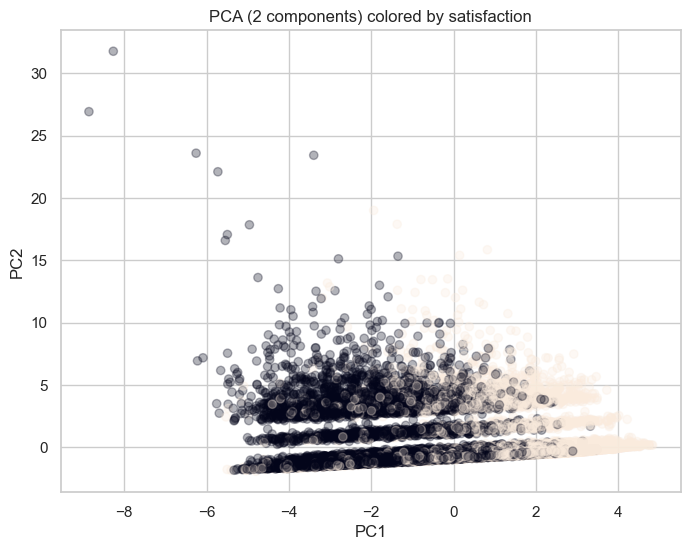

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(pcs[:,0], pcs[:,1], c=y.map({0:0,1:1}), alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (2 components) colored by satisfaction')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CCCCFF; font-size:115%; text-align:left">

Summary of the PCA Plot
- Axes:
    * PC1 (Principal Component 1) and PC2 (Principal Component 2) represent the directions of greatest variance in the dataset.
    * Each point represents a customer (or record) projected into this reduced 2D space.
- Coloring:
    * The points are colored by satisfaction, likely with darker shades representing one class (e.g., dissatisfied) and lighter shades another (e.g., satisfied).
- Observation:
    * The data points do not show a strong separation between the two satisfaction groups — the dark and light points overlap considerably.
    * This suggests that, when reduced to two dimensions, the data’s variance does not clearly distinguish between satisfied and dissatisfied customers.
    * There are some patterns — for example, satisfied customers (lighter points) might be slightly more concentrated on one side (e.g., higher PC1 values), but the clusters are not distinct.

Interpretation
* PCA mainly captures variance, not necessarily class separability. The overlap here implies that:
* Customer satisfaction may depend on nonlinear relationships between features.
* A linear projection (like PCA) may not capture the decision boundaries effectively — a nonlinear model (like Random Forest or XGBoost) is likely more suitable.

In [42]:
# Save results & suggestions
OUT_DIR = Path('./eda_outputs')
OUT_DIR.mkdir(exist_ok=True)

# Save feature importances
feat_imp.head(50).to_csv(OUT_DIR / 'feature_importances_top50.csv')

# Brief suggestions text file
with open(OUT_DIR / 'README_insights.txt', 'w') as f:
    f.write('Summary of EDA and suggested next steps:\n')
    f.write('- Check the impact of long arrival/departure delays on dissatisfaction.\n')
    f.write('- Focus on improving low-rated service features that correlate with dissatisfaction.\n')
    f.write('- Consider stratified models by Class and Customer Type.\n')
    f.write('- Perform hyperparameter tuning and cross-validation for production models.\n')

print('EDA complete. Outputs saved to', OUT_DIR)

EDA complete. Outputs saved to eda_outputs


In [43]:
# End of file